# <span style="color:black; font-weight:bold;">CS9 cynomolgus monkey multi-slices alignment Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 8.24.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 8.24.2026
+ <span style="color:black; font-weight:bold;">Download</span>: CS9cynomolgus monkey multi-slices data used in the tutorial are available at [CS9cynomolgus_monkey.zip](https://drive.google.com/file/d/1ApfJZTp_wch7wcFCkdyCSu8HwtcduA_U/view?usp=sharing).
In this tutorial we apply MAPS to align CS9 cynomolgus monkey multi-slices dataset. We provide two multi-slice alignment schemes, namely sequential alignment and reference alignment.  

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">CS0(ST)</span>: 3039 spots and 4663 genes   
+ <span style="color:black; font-weight:bold;">CS2(ST)</span>: 2986 spots and 4663 genes   
+ <span style="color:black; font-weight:bold;">CS5(ST)</span>: 3275 spots and 4663 genes   
+ <span style="color:black; font-weight:bold;">CS8(ST)</span>: 2969 spots and 4663 genes  
+ <span style="color:black; font-weight:bold;">CS11(ST)</span>: 3487 spots and 4663 genes   
+ <span style="color:black; font-weight:bold;">CS14(ST)</span>: 3194 spots and 4663 genes  
+ <span style="color:black; font-weight:bold;">CS17(ST)</span>: 3800 spots and 4663 genes   
+ <span style="color:black; font-weight:bold;">CS19(ST)</span>: 4167 spots and 4663 genes  
+ <span style="color:black; font-weight:bold;">CS22(ST)</span>: 4171 spots and 4663 genes   
+ <span style="color:black; font-weight:bold;">CS25(ST)</span>: 4480 spots and 4663 genes

In [1]:
from MAPS.align import Multi_slices_rigid_alignment
from MAPS.utils import set_seed
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading CS9 cynomolgus monkey multi-slices data</span>

In [4]:
adata1=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS0_round1.h5ad')
adata1.obs['batch']='CS0'

adata2=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS2_round1.h5ad')
adata2.obs['batch']='CS2'

adata3=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS5_round1.h5ad')
adata3.obs['batch']='CS5'

adata4=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS8_round1.h5ad')
adata4.obs['batch']='CS8'

adata5=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS11_round1.h5ad')
adata5.obs['batch']='CS11'

adata6=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS14_round1.h5ad')
adata6.obs['batch']='CS14'

adata7=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS17_round1.h5ad')
adata7.obs['batch']='CS17'

adata8=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS19_round1.h5ad')
adata8.obs['batch']='CS19'

adata9=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS22_round1.h5ad')
adata9.obs['batch']='CS22'

adata10=sc.read_h5ad('/home/dbj/LPcross/Data/CS9monkey/round_1/CS25_round1.h5ad')
adata10.obs['batch']='CS25'

## <span style="color:black; font-weight:bold;">Spatial mapping of the cynomolgus monkey before alignment</span>

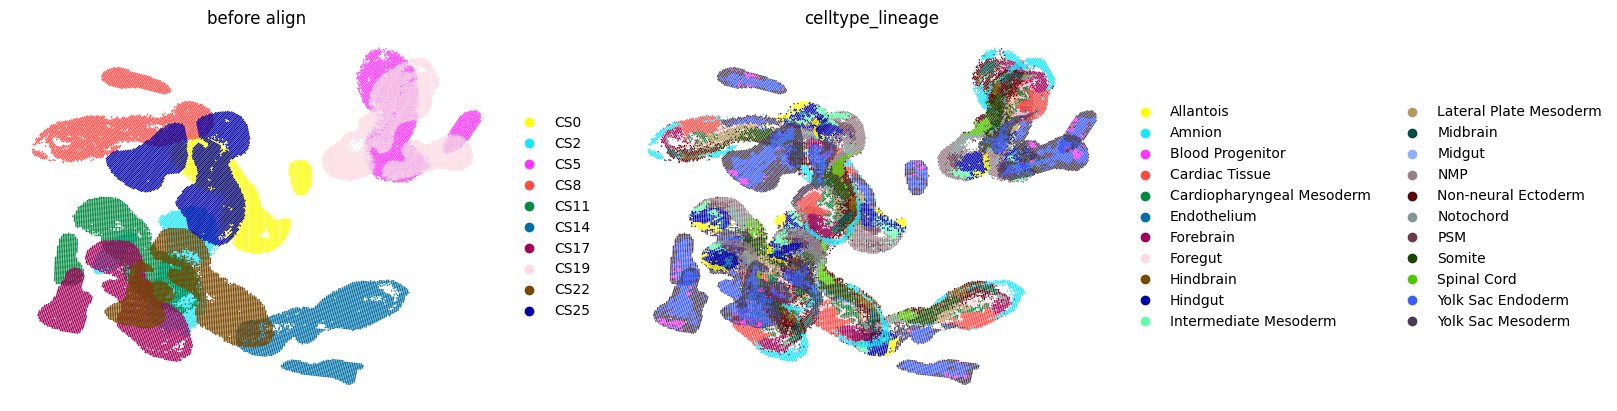

In [5]:
adata_list=[adata1,adata2,adata3,adata4,adata5,adata6,adata7,adata8,adata9,adata10]
adata=sc.concat(adata_list,join='inner')

sc.pl.embedding(adata=adata, basis='spatial',color=['batch','celltype_lineage'],title='before align',size=5,frameon=False,palette=sc.pl.palettes.godsnot_102)

## <span style="color:black; font-weight:bold;">Sequential align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'sequential' The slices are aligned in the order adata_list

### <span style="color:black; font-weight:bold;">Output</span>   
+ sequential_list: A list of slices aligned in order

In [6]:
sequential_list = Multi_slices_rigid_alignment(adata_list, mode='sequential',epochs=500, sample_size=1000, enable_scale=False, device=device)


--- Slice 1 is the first slice ---

--- Aligning Slice 2 to Slice 1 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████████| 500/500 [00:01<00:00, 354.03it/s, Loss=0.92, Scale=1.000, Rot=-143.65°, Trans=(38.0, 62.2)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -143.25°, Translation (x, y): (38.17, 62.99)

--- Aligning Slice 3 to Slice 2 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████████| 500/500 [00:00<00:00, 558.19it/s, Loss=0.94, Scale=1.000, Rot=26.43°, Trans=(-91.7, -56.1)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 27.75°, Translation (x, y): (-91.86, -56.43)

--- Aligning Slice 4 to Slice 3 (sequential alignment) ---
Scanning angles to find best starting angle...


...

Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 60.33°, Translation (x, y): (-83.48, -42.72)

--- Aligning Slice 9 to Slice 8 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████████████████| 500/500 [00:00<00:00, 554.01it/s, Loss=1.07, Scale=1.000, Rot=179.75°, Trans=(31.2, 90.1)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -179.14°, Translation (x, y): (32.04, 89.41)

--- Aligning Slice 10 to Slice 9 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████████████| 500/500 [00:00<00:00, 560.23it/s, Loss=1.11, Scale=1.000, Rot=-144.52°, Trans=(34.7, -10.4)]

Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -144.49°, Translation (x, y): (34.84, -10.36)

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">2D spatial mapping of the sequential alignment result for cynomolgus monkey</span>

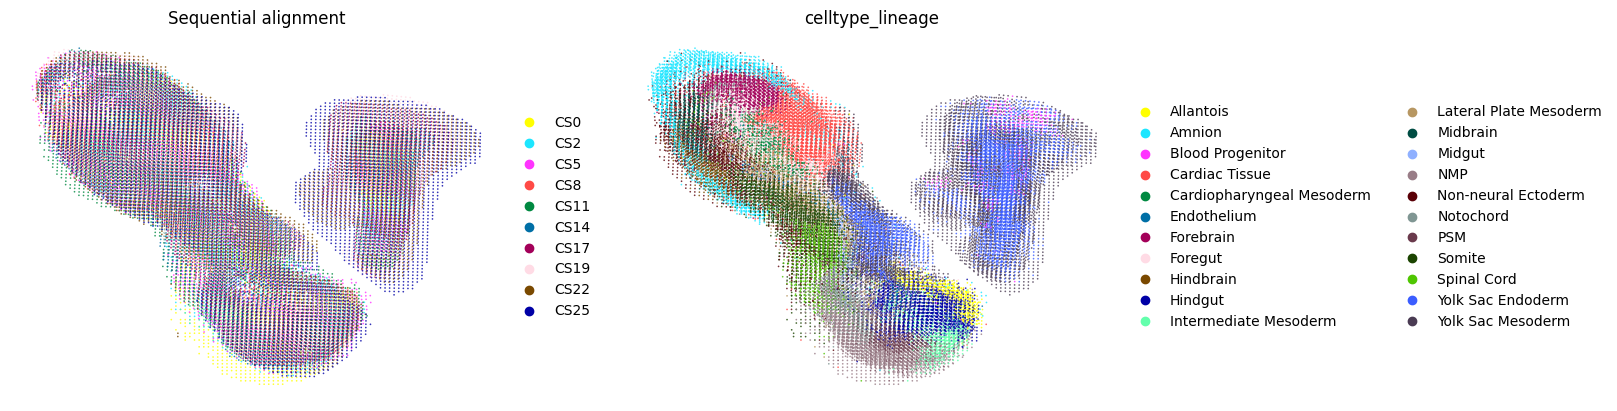

In [7]:
adata=sc.concat(sequential_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','celltype_lineage'],title='Sequential alignment',size=6,alpha=0.8,frameon=False,palette=sc.pl.palettes.godsnot_102)

## <span style="color:black; font-weight:bold;">3D spatial mapping of the sequential alignment result for cynomolgus monkey</span>

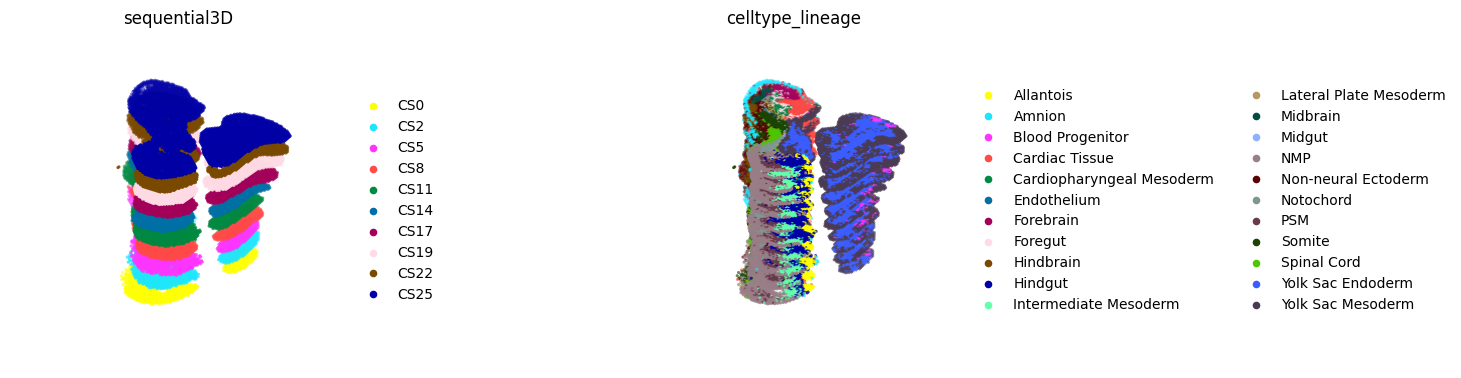

In [8]:
z_spacing = 10 
z_coords = adata.obs['batch'].astype('category').cat.codes.values * z_spacing
coords_3d = np.column_stack([adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], z_coords])
adata.obsm['spatial_3d'] = coords_3d
sc.pl.embedding(adata, basis='spatial_3d', projection='3d', color=['batch', 'celltype_lineage'],title='sequential3D',size=6,frameon=False)

## <span style="color:black; font-weight:bold;">Reference align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'reference' The slices are aligned to the reference target  
+ ref_idx: Reference target, the other slices are aligned to the target slice

### <span style="color:black; font-weight:bold;">Output</span>   
+ reference_list: A list of slices after reference align

In [9]:
reference_list = Multi_slices_rigid_alignment(adata_list, mode='reference', ref_idx=9, epochs=500, sample_size=1000, enable_scale=False, device=device)


--- Aligning Slice 1 to Reference (Slice 10) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████████| 500/500 [00:00<00:00, 566.61it/s, Loss=1.11, Scale=1.000, Rot=149.21°, Trans=(-15.2, 15.2)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 148.72°, Translation (x, y): (-15.13, 14.36)

--- Aligning Slice 2 to Reference (Slice 10) ---
Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████████████████| 500/500 [00:00<00:00, 559.92it/s, Loss=1.11, Scale=1.000, Rot=3.00°, Trans=(19.4, 77.3)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: 2.25°, Translation (x, y): (19.27, 77.93)

--- Aligning Slice 3 to Reference (Slice 10) ---
Scanning angles to find best starting angle...


...

Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -25.56°, Translation (x, y): (43.74, 102.44)

--- Aligning Slice 8 to Reference (Slice 10) ---
Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████████████| 500/500 [00:00<00:00, 565.58it/s, Loss=1.04, Scale=1.000, Rot=-154.68°, Trans=(-114.0, -33.8)]


Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -154.14°, Translation (x, y): (-113.54, -32.67)

--- Aligning Slice 9 to Reference (Slice 10) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████████████| 500/500 [00:00<00:00, 554.34it/s, Loss=1.06, Scale=1.000, Rot=-34.67°, Trans=(2.2, 95.6)]

Peak GPU memory usage: 0.029 GB
Scale factor: 1.000, Rotation angle: -34.51°, Translation (x, y): (2.40, 95.80)

--- Slice 10 is the reference, skipping ---

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">2D spatial mapping of the reference alignment result for cynomolgus monkey</span>

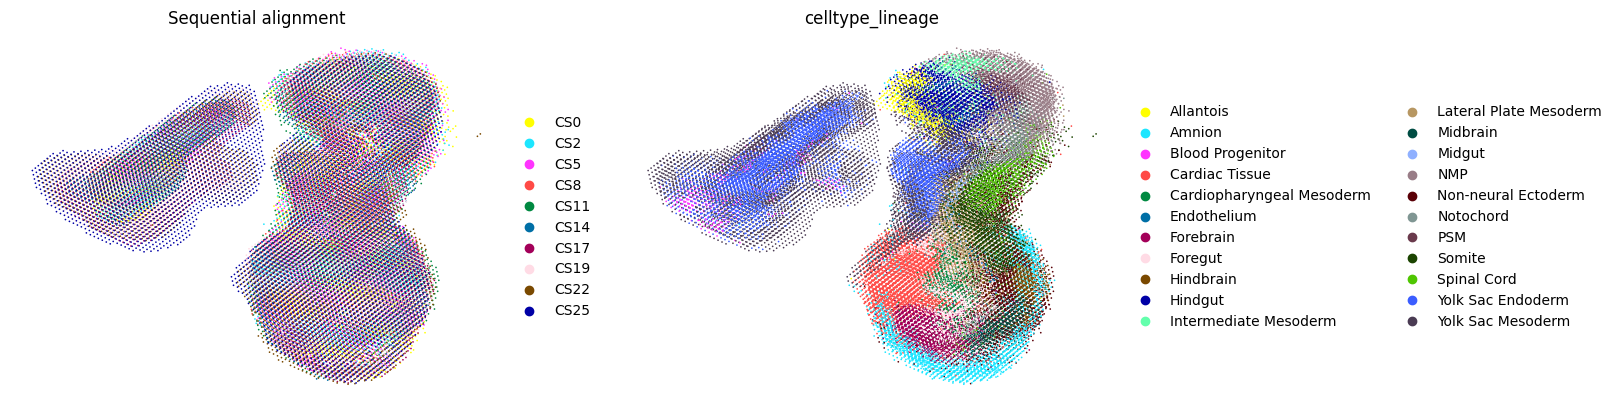

In [10]:
adata=sc.concat(reference_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','celltype_lineage'],title='Sequential alignment',size=6,frameon=False,palette=sc.pl.palettes.godsnot_102)

## <span style="color:black; font-weight:bold;">3D spatial mapping of the reference alignment result for cynomolgus monkey</span> 

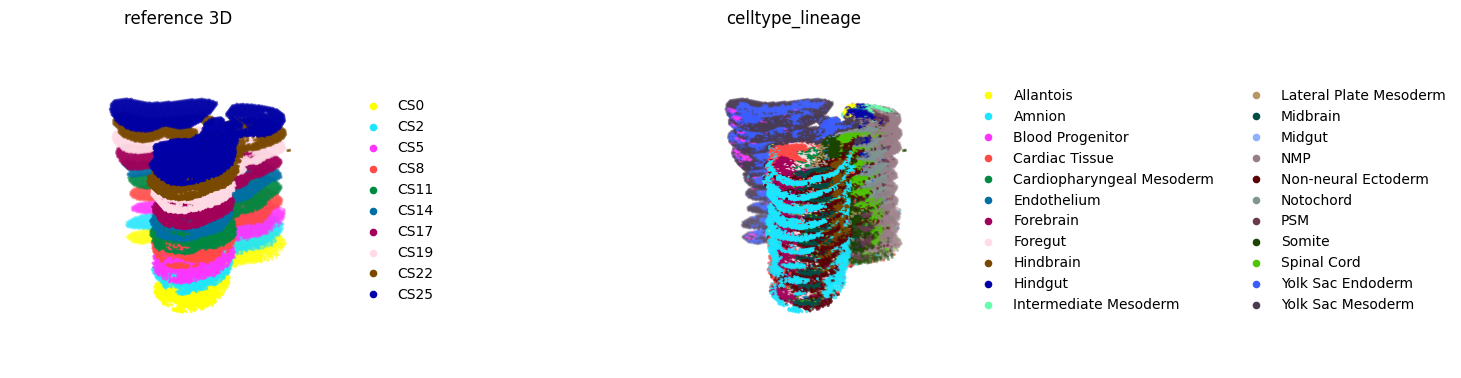

In [11]:
z_spacing = 10 
z_coords = adata.obs['batch'].astype('category').cat.codes.values * z_spacing
coords_3d = np.column_stack([adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], z_coords])
adata.obsm['spatial_3d'] = coords_3d
sc.pl.embedding(adata, basis='spatial_3d', projection='3d', color=['batch', 'celltype_lineage'],title='reference 3D',size=6,frameon=False)